In [1]:
import logging
from nlab_modbus.manager import DeviceManager
import time
import matplotlib.pyplot as plt


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
    force=True
)
logging.getLogger("pymodbus").setLevel(logging.CRITICAL)
logging.getLogger("pymodbus.logging").setLevel(logging.CRITICAL)


In [2]:
mgr = DeviceManager()

In [3]:
ips = await mgr.scan_remote_ips_async()
print(ips)

['192.168.10.128', '192.168.10.134']


In [4]:
mgr.scan_local_ports()

2026-05-28 15:20:37,338 | INFO     | nlab_modbus.discovery.scan | Register found: 257


In [5]:
mgr.local

In [6]:
mgr.local[0].connection_info()

'serial://COM6:1'

In [7]:
mgr.local[0].get_board_temp()

27.8

In [8]:
for ip in ips:
    mgr.scan_remote(ip, [5001, 5002])

2026-05-28 15:20:43,253 | INFO     | nlab_modbus.discovery.scan | Register found: 769
2026-05-28 15:20:45,343 | INFO     | nlab_modbus.discovery.scan | Register found: 257
2026-05-28 15:20:45,387 | INFO     | nlab_modbus.discovery.scan | Register found: 513


In [9]:
mgr.remote

In [10]:
mgr.remote[0].set_pwm_enable(1)

In [11]:
mgr.all_devices

In [12]:
mgr.close_all()

In [13]:
mgr.local[0].connect()

In [14]:
temps = []
counts = []
times = []
t0 = time.monotonic()
dt = 0.25
next_time = t0 + dt  # Absolute target for first
for i in range(200):
    t_loop_0 = time.time()
    temp = mgr.local[0].get_board_temp()
    cps = mgr.remote[2].get_pulses_per_sec()
    temps.append(temp)
    counts.append(cps)
    times.append(time.monotonic() - t0)
    print(f"{times[-1]:8.2f} s, {temp:7.2f} °C, {cps:6d} cps", end="\r")
    t_loop = time.time() - t_loop_0
    next_time += dt
    sleep_dur = next_time - time.monotonic()
    if sleep_dur > 0:
        time.sleep(sleep_dur)

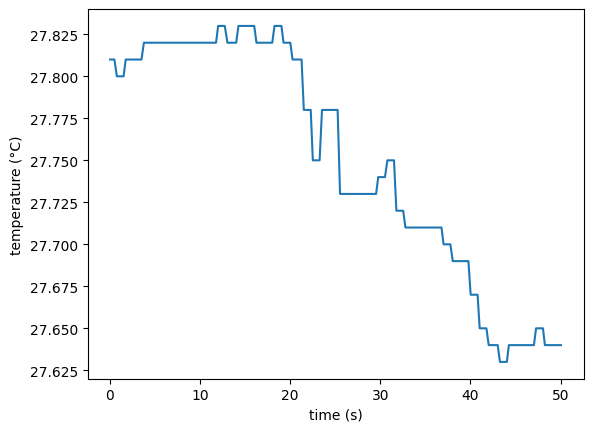

In [15]:
plt.figure()
plt.plot(times, temps)
plt.xlabel('time (s)')
plt.ylabel('temperature (°C)')
plt.show()

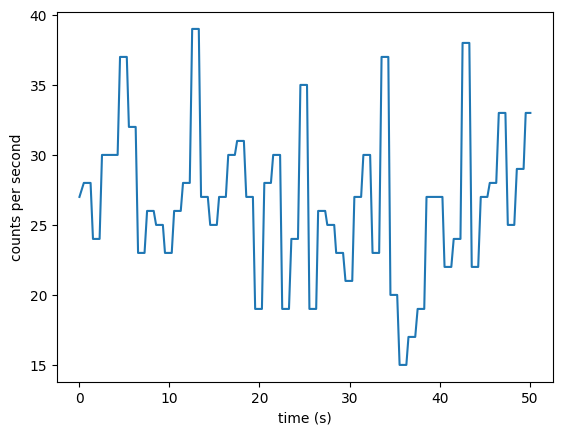

In [16]:
plt.figure()
plt.plot(times, counts)
plt.xlabel('time (s)')
plt.ylabel('counts per second')
plt.show()

In [17]:
import numpy as np

In [18]:
np.array(times[1:]) - np.array(times[:-1])

array([0.484, 0.266, 0.234, 0.25 , 0.266, 0.234, 0.266, 0.234, 0.266,
       0.234, 0.25 , 0.266, 0.234, 0.266, 0.234, 0.25 , 0.266, 0.234,
       0.25 , 0.266, 0.234, 0.266, 0.234, 0.25 , 0.266, 0.234, 0.266,
       0.218, 0.282, 0.234, 0.266, 0.234, 0.266, 0.218, 0.266, 0.266,
       0.234, 0.25 , 0.266, 0.234, 0.266, 0.234, 0.266, 0.234, 0.25 ,
       0.266, 0.234, 0.25 , 0.266, 0.218, 0.297, 0.219, 0.25 , 0.266,
       0.234, 0.25 , 0.266, 0.234, 0.266, 0.234, 0.25 , 0.266, 0.234,
       0.25 , 0.266, 0.234, 0.266, 0.234, 0.25 , 0.266, 0.234, 0.25 ,
       0.266, 0.234, 0.266, 0.234, 0.25 , 0.266, 0.234, 0.25 , 0.266,
       0.234, 0.266, 0.234, 0.25 , 0.266, 0.234, 0.266, 0.234, 0.25 ,
       0.266, 0.234, 0.266, 0.218, 0.282, 0.234, 0.266, 0.234, 0.266,
       0.234, 0.266, 0.234, 0.25 , 0.266, 0.218, 0.282, 0.234, 0.266,
       0.234, 0.266, 0.234, 0.266, 0.218, 0.282, 0.25 , 0.234, 0.266,
       0.234, 0.25 , 0.266, 0.234, 0.266, 0.234, 0.25 , 0.25 , 0.266,
       0.234, 0.25 ,

(array([10., 68., 40.,  0., 72.,  7.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.218     , 0.22908333, 0.24016667, 0.25125   , 0.26233333,
        0.27341667, 0.2845    , 0.29558333, 0.30666667, 0.31775   ,
        0.32883333, 0.33991667, 0.351     , 0.36208333, 0.37316667,
        0.38425   , 0.39533333, 0.40641667, 0.4175    , 0.42858333,
        0.43966667, 0.45075   , 0.46183333, 0.47291667, 0.484     ]),
 <BarContainer object of 24 artists>)

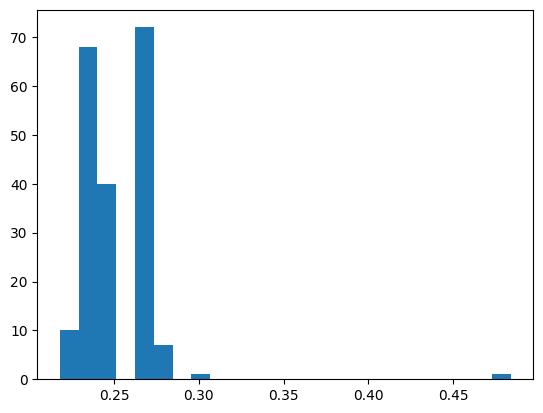

In [19]:
plt.hist(np.array(times[1:]) - np.array(times[:-1]), bins=24)